# Olist Brazilian E-Commerce: Customer Intelligence Analysis
**Why 97% of Olist Buyers Never Come Back — and What to Do About It**

Dataset: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
Period: September 2016 – October 2018

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

con = duckdb.connect('../db/olist.duckdb', read_only=True)
print('Connected to DuckDB warehouse.')

IOException: IO Error: Cannot open database "/Users/tess/NTU/M2/Project/analysis/db/olist.duckdb" in read-only mode: database does not exist

---
## 1. Monthly Sales Trends

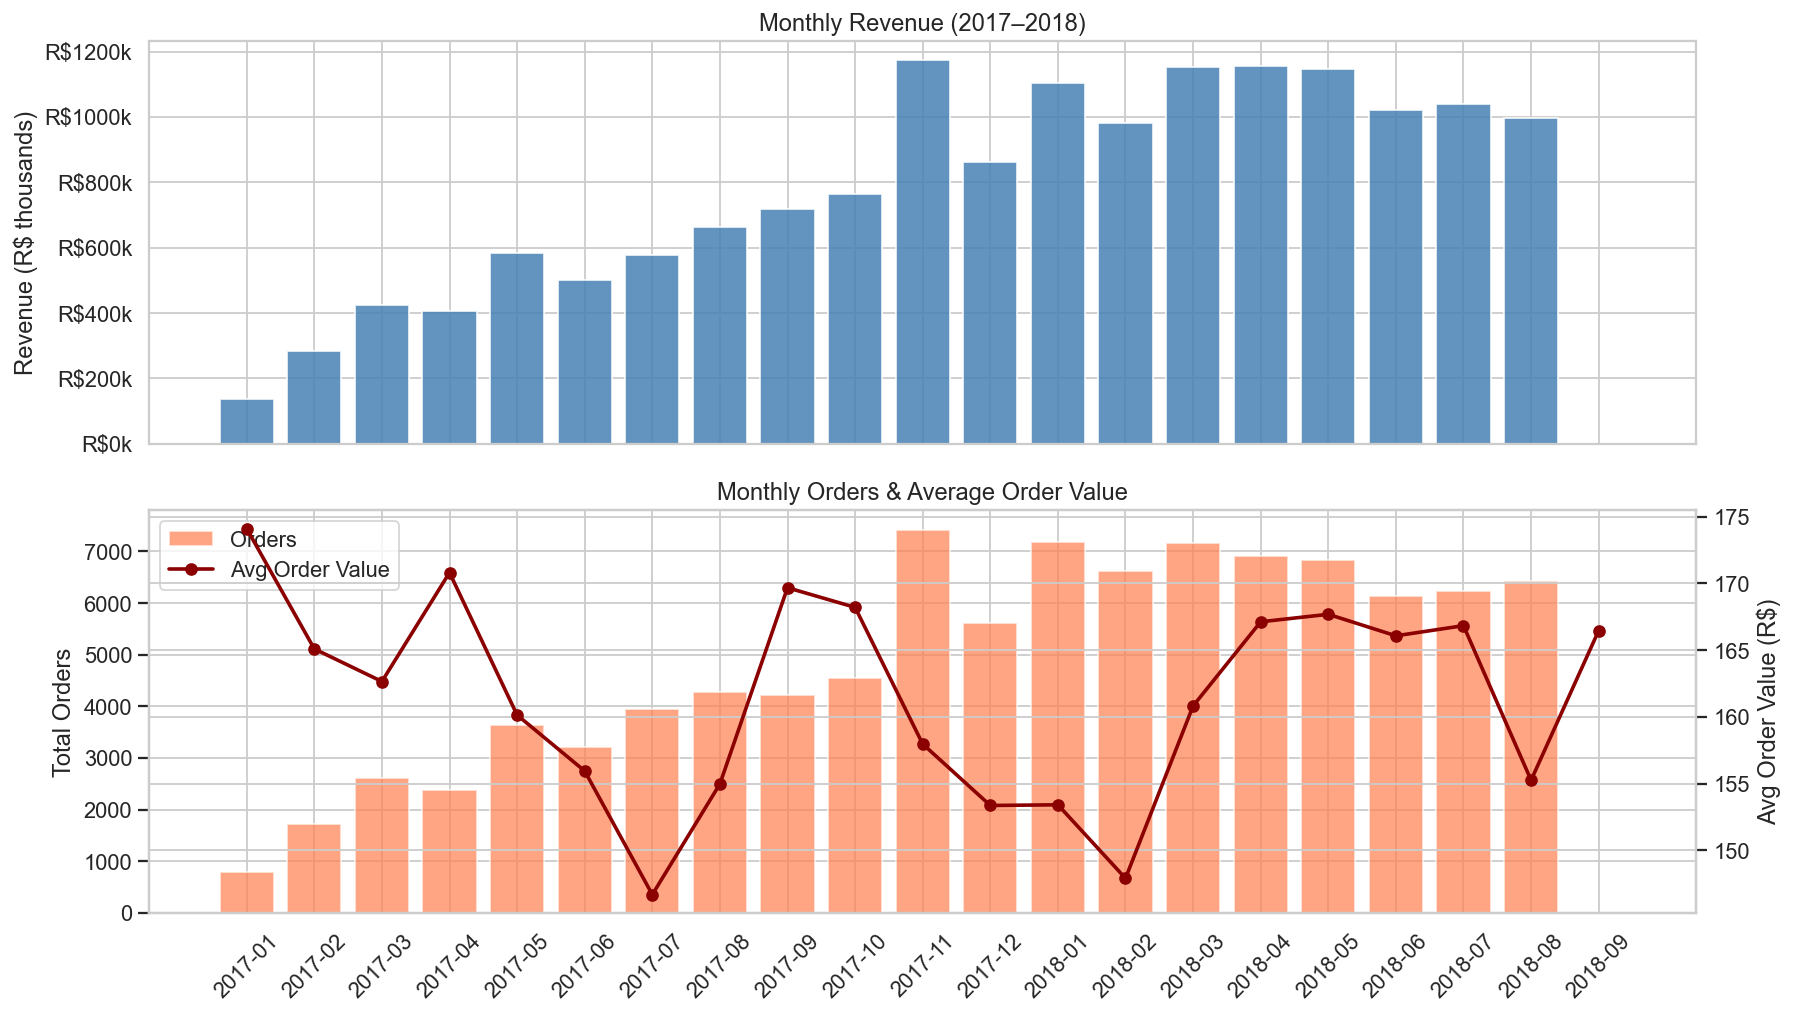

Peak month: 2017-11 — R$1,172,639
Total 2017-2018 revenue: R$15,687,324


In [ ]:
monthly = con.execute("""
    SELECT * FROM mart.monthly_sales ORDER BY month_start
""").df()

monthly['month_label'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Revenue
axes[0].bar(monthly['month_label'], monthly['total_revenue'] / 1e3, color='steelblue', alpha=0.85)
axes[0].set_ylabel('Revenue (R$ thousands)')
axes[0].set_title('Monthly Revenue (2017–2018)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

# Orders & avg order value
ax2 = axes[1].twinx()
axes[1].bar(monthly['month_label'], monthly['total_orders'], color='coral', alpha=0.7, label='Orders')
ax2.plot(monthly['month_label'], monthly['avg_order_value'], color='darkred', marker='o', linewidth=2, label='Avg Order Value')
axes[1].set_ylabel('Total Orders')
ax2.set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Monthly Orders & Average Order Value')
axes[1].tick_params(axis='x', rotation=45)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../docs/monthly_sales.png', bbox_inches='tight')
plt.show()

print(f"Peak month: {monthly.loc[monthly.total_revenue.idxmax(), 'month_label']} — R${monthly.total_revenue.max():,.0f}")
print(f"Total 2017-2018 revenue: R${monthly.total_revenue.sum():,.0f}")

---
## 2. Customer RFM Segmentation

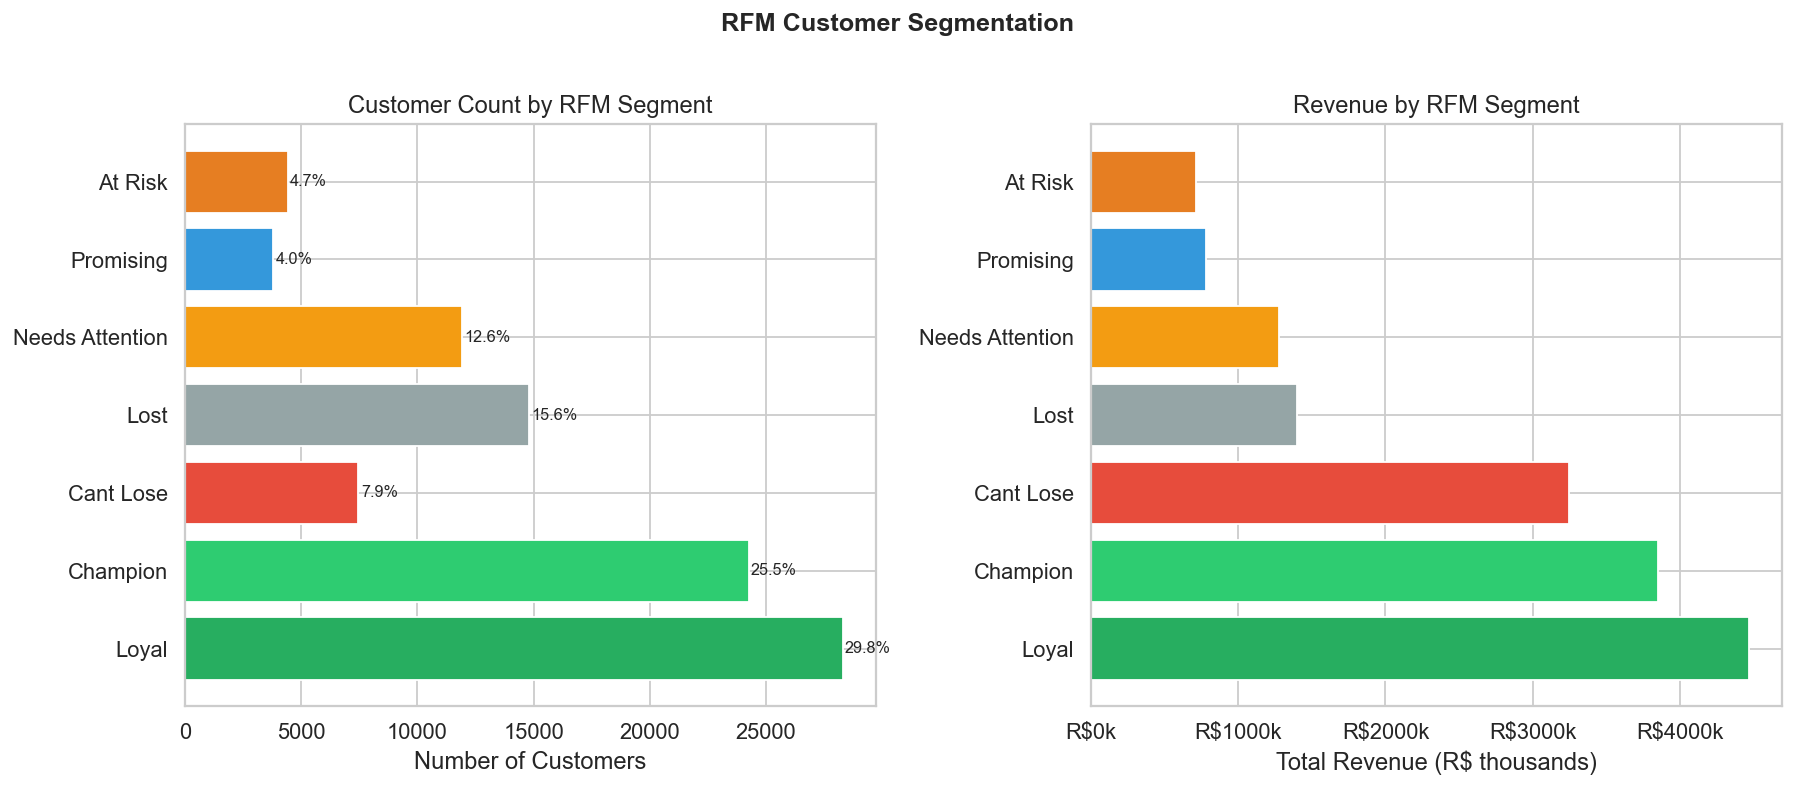

        segment  count       pct  total_revenue
          Loyal  28312 29.805243     4467540.54
       Champion  24263 25.542689     3849553.24
      Cant Lose   7462  7.855564     3249295.14
           Lost  14796 15.576376     1401873.79
Needs Attention  11937 12.566586     1277118.58
      Promising   3801  4.001474      779596.30
        At Risk   4419  4.652069      714159.42


In [ ]:
rfm = con.execute("SELECT * FROM mart.customer_rfm").df()

seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
seg_counts['pct'] = 100 * seg_counts['count'] / seg_counts['count'].sum()

seg_revenue = rfm.groupby('segment')['monetary'].sum().reset_index()
seg_revenue.columns = ['segment', 'total_revenue']
seg_summary = seg_counts.merge(seg_revenue, on='segment').sort_values('total_revenue', ascending=False)

SEGMENT_COLORS = {
    'Champion':       '#2ecc71',
    'Loyal':          '#27ae60',
    'Promising':      '#3498db',
    'Needs Attention':'#f39c12',
    'At Risk':        '#e67e22',
    'Cant Lose':      '#e74c3c',
    'Lost':           '#95a5a6',
}
colors = [SEGMENT_COLORS.get(s, '#bdc3c7') for s in seg_summary['segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(seg_summary['segment'], seg_summary['count'], color=colors)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by RFM Segment')
for i, (count, pct) in enumerate(zip(seg_summary['count'], seg_summary['pct'])):
    axes[0].text(count + 100, i, f'{pct:.1f}%', va='center', fontsize=9)

axes[1].barh(seg_summary['segment'], seg_summary['total_revenue'] / 1e3, color=colors)
axes[1].set_xlabel('Total Revenue (R$ thousands)')
axes[1].set_title('Revenue by RFM Segment')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/rfm_segments.png', bbox_inches='tight')
plt.show()

print(seg_summary[['segment','count','pct','total_revenue']].to_string(index=False))

In [ ]:
# Repeat purchase rate — the headline finding
total = len(rfm)
repeat = (rfm['frequency'] > 1).sum()
repeat_rev = rfm[rfm['frequency'] > 1]['monetary'].sum()
total_rev = rfm['monetary'].sum()

print(f"Total unique customers: {total:,}")
print(f"Repeat buyers (2+ orders): {repeat:,} ({100*repeat/total:.1f}%)")
print(f"Revenue from repeat buyers: R${repeat_rev:,.0f} ({100*repeat_rev/total_rev:.1f}% of total revenue)")
print(f"\nAvg monetary value — one-time: R${rfm[rfm.frequency==1].monetary.mean():.2f}")
print(f"Avg monetary value — repeat:   R${rfm[rfm.frequency>1].monetary.mean():.2f}")

Total unique customers: 94,990
Repeat buyers (2+ orders): 2,888 (3.0%)
Revenue from repeat buyers: R$890,534 (5.7% of total revenue)

Avg monetary value — one-time: R$161.22
Avg monetary value — repeat:   R$308.36


---
## 3. Delivery Performance vs Customer Satisfaction

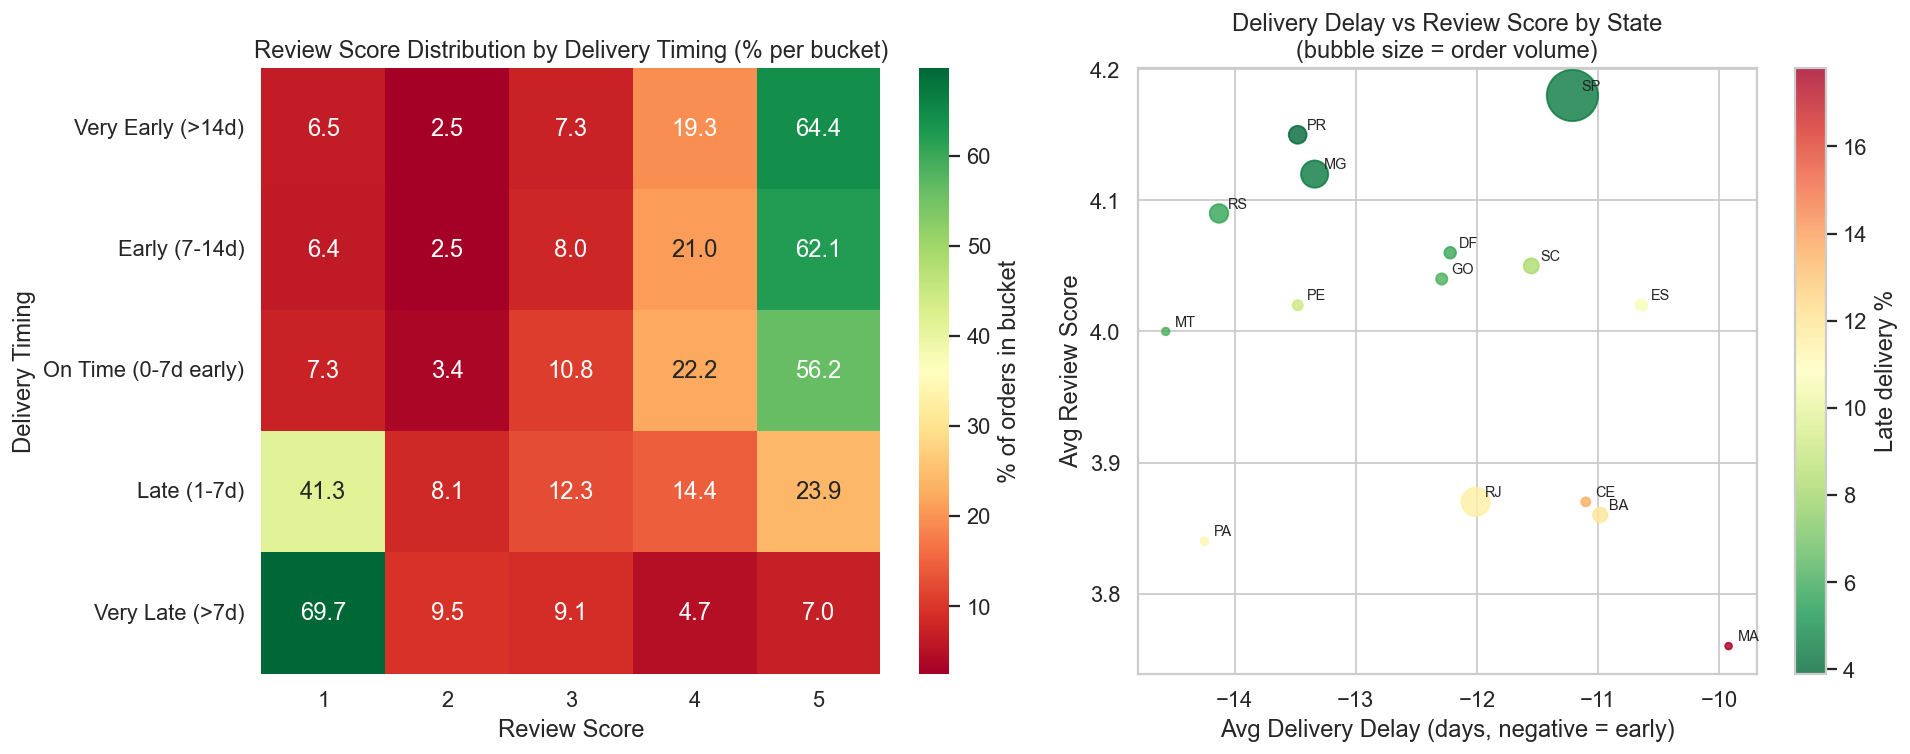

In [ ]:
sat = con.execute("SELECT * FROM mart.satisfaction_vs_delivery").df()

pivot = sat.pivot(index='delivery_bucket', columns='review_score', values='order_count').fillna(0)
bucket_order = ['Very Early (>14d)', 'Early (7-14d)', 'On Time (0-7d early)', 'Late (1-7d)', 'Very Late (>7d)']
pivot = pivot.reindex([b for b in bucket_order if b in pivot.index])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
pct_pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pct_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': '% of orders in bucket'})
axes[0].set_title('Review Score Distribution by Delivery Timing (% per bucket)')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Delivery Timing')

# Avg score by state
state_del = con.execute("""
    SELECT customer_state, avg_review_score, avg_delay_days, total_orders, late_pct
    FROM mart.delivery_by_state
    ORDER BY total_orders DESC LIMIT 15
""").df()

scatter = axes[1].scatter(
    state_del['avg_delay_days'],
    state_del['avg_review_score'],
    s=state_del['total_orders'] / 50,
    c=state_del['late_pct'],
    cmap='RdYlGn_r',
    alpha=0.8
)
for _, row in state_del.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delay_days'], row['avg_review_score']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(scatter, ax=axes[1], label='Late delivery %')
axes[1].set_xlabel('Avg Delivery Delay (days, negative = early)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Delivery Delay vs Review Score by State\n(bubble size = order volume)')

plt.tight_layout()
plt.savefig('../docs/delivery_satisfaction.png', bbox_inches='tight')
plt.show()

---
## 4. Top Product Categories

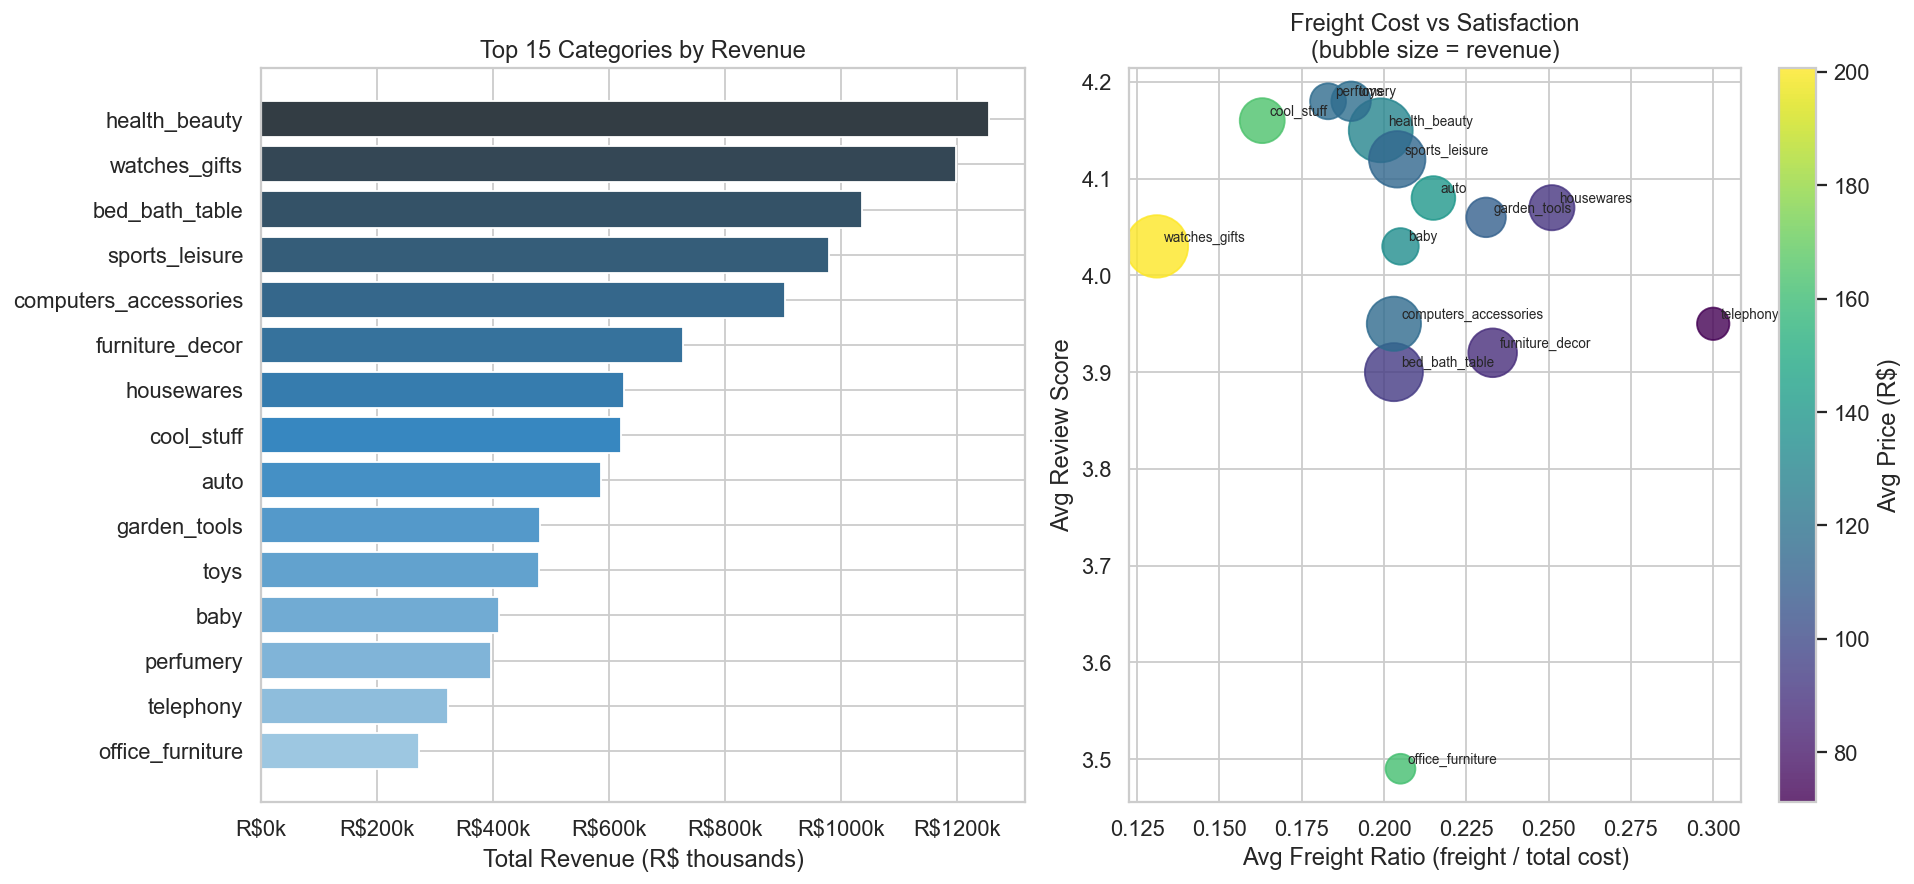

In [ ]:
cats = con.execute("""
    SELECT category, total_revenue, units_sold, avg_price,
           avg_freight_ratio, avg_review_score
    FROM mart.category_performance
    ORDER BY total_revenue DESC LIMIT 15
""").df()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Revenue
bars = axes[0].barh(cats['category'][::-1], cats['total_revenue'][::-1] / 1e3,
                    color=sns.color_palette('Blues_d', 15))
axes[0].set_xlabel('Total Revenue (R$ thousands)')
axes[0].set_title('Top 15 Categories by Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

# Freight ratio vs avg review (bubble = revenue)
scatter = axes[1].scatter(
    cats['avg_freight_ratio'],
    cats['avg_review_score'],
    s=cats['total_revenue'] / 1000,
    c=cats['avg_price'],
    cmap='viridis',
    alpha=0.8
)
for _, row in cats.iterrows():
    axes[1].annotate(row['category'],
                     (row['avg_freight_ratio'], row['avg_review_score']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7.5)
plt.colorbar(scatter, ax=axes[1], label='Avg Price (R$)')
axes[1].set_xlabel('Avg Freight Ratio (freight / total cost)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Freight Cost vs Satisfaction\n(bubble size = revenue)')

plt.tight_layout()
plt.savefig('../docs/category_performance.png', bbox_inches='tight')
plt.show()

---
## 5. Geographic Market Opportunity

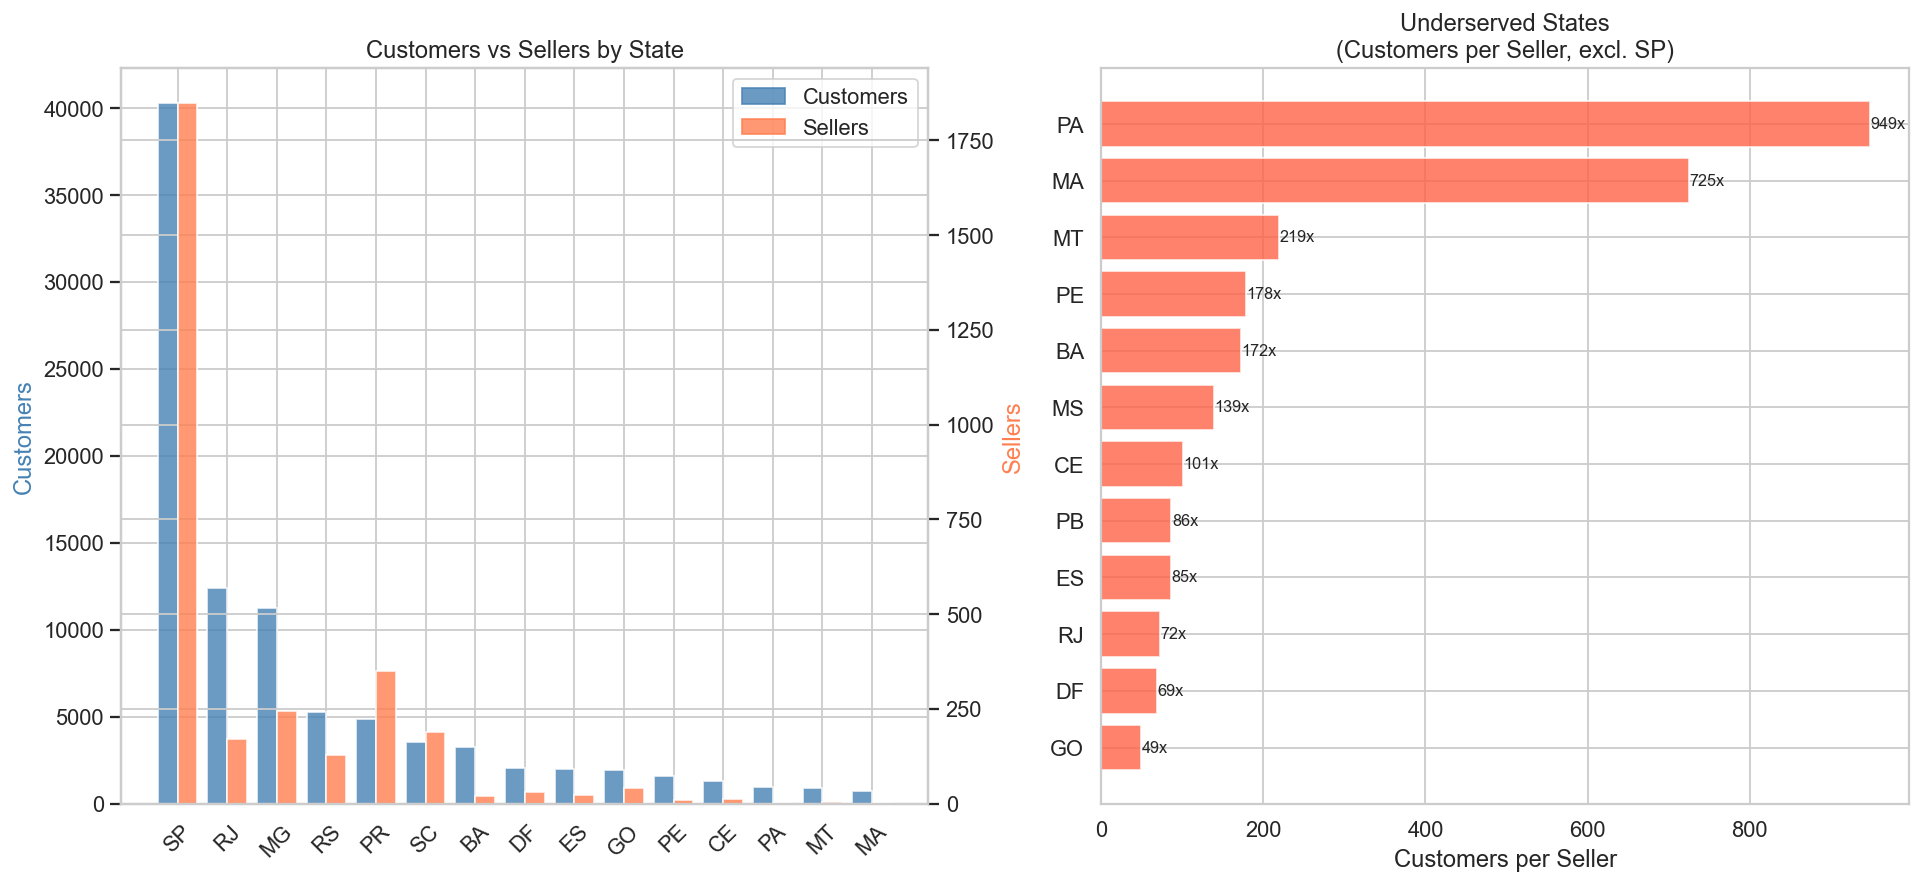

Top underserved states (customers/seller):
state  customers  sellers  customers_per_seller
   PA        949        1            949.000000
   MA        725        1            725.000000
   MT        875        4            218.800003
   PE       1604        9            178.199997
   BA       3276       19            172.399994
   MS        694        5            138.800003
   CE       1311       13            100.800003
   PB        519        6             86.500000
   ES       1964       23             85.400002
   RJ      12383      171             72.400002
   DF       2073       30             69.099998
   GO       1950       40             48.799999


In [ ]:
geo = con.execute("""
    WITH customer_state AS (
        SELECT state, COUNT(*) AS customers
        FROM warehouse.dim_customers
        GROUP BY state
    ),
    seller_state AS (
        SELECT state, COUNT(*) AS sellers
        FROM warehouse.dim_sellers
        GROUP BY state
    )
    SELECT
        c.state,
        c.customers,
        COALESCE(s.sellers, 0) AS sellers,
        ROUND(c.customers::FLOAT / NULLIF(COALESCE(s.sellers, 0), 0), 1) AS customers_per_seller
    FROM customer_state c
    LEFT JOIN seller_state s USING (state)
    ORDER BY c.customers DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top15 = geo.head(15)
x = range(len(top15))
width = 0.4

ax2 = axes[0].twinx()
axes[0].bar([i - width/2 for i in x], top15['customers'], width, label='Customers', color='steelblue', alpha=0.8)
ax2.bar([i + width/2 for i in x], top15['sellers'], width, label='Sellers', color='coral', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(top15['state'], rotation=45)
axes[0].set_ylabel('Customers', color='steelblue')
ax2.set_ylabel('Sellers', color='coral')
axes[0].set_title('Customers vs Sellers by State')
p1 = mpatches.Patch(color='steelblue', alpha=0.8, label='Customers')
p2 = mpatches.Patch(color='coral',     alpha=0.8, label='Sellers')
axes[0].legend(handles=[p1, p2], loc='upper right')

# Underserved states (high customers/seller ratio, excl SP)
underserved = geo[(geo['state'] != 'SP') & (geo['customers'] >= 500)].sort_values('customers_per_seller', ascending=False).head(12)
axes[1].barh(underserved['state'][::-1], underserved['customers_per_seller'][::-1], color='tomato', alpha=0.8)
axes[1].set_xlabel('Customers per Seller')
axes[1].set_title('Underserved States\n(Customers per Seller, excl. SP)')
for i, (val, state) in enumerate(zip(underserved['customers_per_seller'][::-1], underserved['state'][::-1])):
    axes[1].text(val + 0.5, i, f'{val:.0f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/geo_opportunity.png', bbox_inches='tight')
plt.show()

print("Top underserved states (customers/seller):")
print(underserved[['state','customers','sellers','customers_per_seller']].to_string(index=False))

---
## 6. Executive Summary

In [ ]:
summary = con.execute("""
    SELECT
        COUNT(DISTINCT order_id)                             AS total_orders,
        COUNT(DISTINCT customer_key)                         AS unique_customers,
        ROUND(SUM(total_payment), 0)                         AS total_revenue,
        ROUND(AVG(total_payment), 2)                         AS avg_order_value,
        ROUND(AVG(avg_review_score), 2)                      AS avg_review_score,
        ROUND(AVG(CASE WHEN delivery_delay_days IS NOT NULL
                       THEN delivery_delay_days END), 2)     AS avg_delivery_delay,
        SUM(CASE WHEN delivery_delay_days > 0 THEN 1 END)    AS late_orders
    FROM warehouse.fact_orders
    WHERE order_status NOT IN ('canceled','unavailable')
""").df()

rfm_seg = con.execute("""
    SELECT segment, COUNT(*) AS n,
           ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM mart.customer_rfm
    GROUP BY segment ORDER BY n DESC
""").df()

print("=" * 55)
print("  OLIST EXECUTIVE SUMMARY")
print("=" * 55)
r = summary.iloc[0]
print(f"  Period:              Sep 2016 – Oct 2018")
print(f"  Total Orders:        {int(r.total_orders):,}")
print(f"  Unique Customers:    {int(r.unique_customers):,}")
print(f"  Total Revenue:       R${int(r.total_revenue):,}")
print(f"  Avg Order Value:     R${r.avg_order_value}")
print(f"  Avg Review Score:    {r.avg_review_score} / 5.0")
print(f"  Avg Delivery Delay:  {r.avg_delivery_delay} days (neg = early)")
print(f"  Late Deliveries:     {int(r.late_orders):,}")
print()
print("  CUSTOMER SEGMENTS:")
for _, row in rfm_seg.iterrows():
    print(f"  {row.segment:<18} {int(row.n):>7,}  ({row.pct}%)")
print("=" * 55)

print("""
KEY INSIGHTS:
1. 96.9% of customers never return → fixing retention is the #1 lever
2. Delivery communication gap: even orders arriving 4 days early get 1-star reviews
   → customers' expectations are set too optimistically
3. Non-SP states face 2–5x higher freight ratios with fewer local sellers
   → expanding the seller base outside SP could unlock significant revenue
4. Health & Beauty, Watches, Bed/Bath are top revenue categories — all amenable
   to subscription/repeat purchase models if retention is addressed
""")

con.close()

  OLIST EXECUTIVE SUMMARY
  Period:              Sep 2016 – Oct 2018
  Total Orders:        98,207
  Unique Customers:    94,990
  Total Revenue:       R$15,739,137
  Avg Order Value:     R$160.26
  Avg Review Score:    4.12 / 5.0
  Avg Delivery Delay:  -11.88 days (neg = early)
  Late Deliveries:     6,534

  CUSTOMER SEGMENTS:
  Loyal               28,312  (29.8%)
  Champion            24,263  (25.5%)
  Lost                14,796  (15.6%)
  Needs Attention     11,937  (12.6%)
  Cant Lose            7,462  (7.9%)
  At Risk              4,419  (4.7%)
  Promising            3,801  (4.0%)

KEY INSIGHTS:
1. 96.9% of customers never return → fixing retention is the #1 lever
2. Delivery communication gap: even orders arriving 4 days early get 1-star reviews
   → customers' expectations are set too optimistically
3. Non-SP states face 2–5x higher freight ratios with fewer local sellers
   → expanding the seller base outside SP could unlock significant revenue
4. Health & Beauty, Watches, Bed